# v06 — Backtest: TP/SL ATR-relatif (fix distribution shift dari live trading)

**Latar belakang:** robot live (parameter v04, TP=12pt/SL=6pt FIXED) dijalankan di akun demo
7 Agustus 2026 — hasilnya **69 trade, 67 LOSS, 2 WIN (win rate 2.9%), total -$402.89**. Jauh dari
hasil backtest v04 (win rate 44.5%).

**Investigasi akar masalah (sebelum notebook ini):**
- Semua 69 trade adalah BUY, dan arah market **memang naik** (harga $4318->$4354) -- jadi arah
  sinyal SUDAH BENAR, bukan salah baca arah
- SL fixed 6 poin ternyata cuma **~70-100% dari ATR saat itu** (ATR rata-rata $6.7, kadang $9.5) --
  SL terlalu sempit relatif terhadap volatilitas candle M5 di rezim harga sekarang
- **v04 dituning/backtest di data 2025 dengan harga XAUUSD $2600-2789**. Robot live jalan di
  **Agustus 2026 dengan harga $4300+**. Di rezim harga setinggi ini, pergerakan candle secara POIN
  ABSOLUT jauh lebih besar -- TP/SL fixed poin yang dulu wajar sekarang terlalu sempit, gampang
  kena "guncangan" candle sebelum harga lanjut ke arah yang benar
- Ini pola **distribution shift** yang sama dengan yang ditemukan di v05 (ML) sebelumnya

**Perbaikan di v06:** ganti TP/SL dari fixed poin ke **ATR-relatif** (`SL = k1 x ATR`,
`TP = k2 x ATR`, dihitung ULANG tiap candle dari ATR saat itu) -- otomatis menyesuaikan skala
harga & volatilitas, jadi tidak rentan distribution shift kalau harga terus naik/rezim berubah.

**Yang TIDAK diubah** (supaya perbandingan adil, cuma TP/SL yang diuji): signal scoring
(`MIN_SIGNAL_SCORE=9.0`, filter H1 alignment, ADX/ATR minimum) tetap sama seperti v04.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from app.utils.signals import generate_signal

STRATEGY_NAME = "m5_scalping"
VERSION = "v06"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
PROCESSED_OUT_DIR = PROCESSED_DIR / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load dataset M5 + H1 (sama seperti v02-v04)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df_h1 = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
df_h1["datetime"] = pd.to_datetime(df_h1["datetime"])
df_h1 = df_h1.sort_values("datetime").reset_index(drop=True)

df_h1_shifted = df_h1.copy()
df_h1_shifted["h1_available_at"] = df_h1_shifted["datetime"] + pd.Timedelta(hours=1)
h1_value_cols = [c for c in df_h1_shifted.columns if c != "h1_available_at"]
df_h1_shifted = df_h1_shifted[["h1_available_at", *h1_value_cols]].rename(
    columns={c: f"h1_{c}" for c in h1_value_cols}
)

df = pd.merge_asof(
    df.sort_values("datetime"),
    df_h1_shifted.sort_values("h1_available_at"),
    left_on="datetime",
    right_on="h1_available_at",
    direction="backward",
)

print("M5 + konteks H1:", df.shape, df["datetime"].min(), "->", df["datetime"].max())

M5 + konteks H1: (518403, 151) 2019-01-01 23:00:00+00:00 -> 2026-08-06 12:35:00+00:00


## 2. Generate sinyal (parameter v04, TIDAK diubah)

Backtest di **seluruh 2025-2026** dulu (spt v04) untuk perbandingan apple-to-apple, lalu evaluasi
terpisah khusus periode **2026 rezim harga tinggi** ($3900+) yang jadi sumber masalah live trading.

In [3]:
BACKTEST_START = "2025-01-01"
df_bt = df[df["datetime"] >= BACKTEST_START].reset_index(drop=True)

MIN_SIGNAL_SCORE = 9.0
ADX_MIN = 18.0
ATR_MIN_PCT = 0.03
REQUIRE_H1_ALIGNMENT = True

directions = np.empty(len(df_bt), dtype=object)
scores = np.zeros(len(df_bt))
for pos, (_, row) in enumerate(df_bt.iterrows()):
    result = generate_signal(row, MIN_SIGNAL_SCORE, ADX_MIN, ATR_MIN_PCT, REQUIRE_H1_ALIGNMENT)
    directions[pos] = result.direction
    scores[pos] = result.final_score

df_bt["signal_direction"] = directions
df_bt["signal_score"] = scores

print("Baris backtest:", len(df_bt))
df_bt["signal_direction"].value_counts()

Baris backtest: 107336


signal_direction
WAIT    103287
BUY       2498
SELL      1551
Name: count, dtype: int64

## 3. Backtest engine dengan TP/SL ATR-relatif

`SL = sl_mult x ATR`, `TP = tp_mult x ATR`, dihitung dari `ind_atr` candle saat entry (bukan poin
fixed) -- otomatis mengikuti skala volatilitas & harga saat itu.

In [4]:
INITIAL_EQUITY = 100.0
RISK_PCT = 0.01
MAX_HOLD_CANDLES = 12
CONTRACT_SIZE = 100.0
MIN_LOT = 0.01
LOT_STEP = 0.01
SPREAD_POINTS = 0.30

RAW_INDICATOR_COLUMNS = [c for c in df_bt.columns if c not in ("timestamp", "datetime")]


def calc_lot(equity: float, risk_pct: float, sl_distance: float) -> float:
    if sl_distance <= 0 or equity <= 0:
        return MIN_LOT
    risk_amount = equity * risk_pct
    raw_lot = risk_amount / (sl_distance * CONTRACT_SIZE)
    lot = math.floor(raw_lot / LOT_STEP) * LOT_STEP
    return max(round(lot, 2), MIN_LOT)


def run_backtest_atr(df_signals: pd.DataFrame, sl_mult: float, tp_mult: float,
                      max_hold_candles: int, save_full_log: bool = False) -> tuple[pd.DataFrame, list[float]]:
    trades = []
    equity = INITIAL_EQUITY
    equity_curve = [equity]
    i = 0
    n = len(df_signals)

    while i < n:
        row = df_signals.iloc[i]
        direction = row["signal_direction"]

        if direction == "WAIT":
            i += 1
            continue

        atr = row["atr"]
        if not np.isfinite(atr) or atr <= 0:
            i += 1
            continue

        sl_points = sl_mult * atr
        tp_points = tp_mult * atr

        entry_price = row["close"] + (SPREAD_POINTS if direction == "BUY" else -SPREAD_POINTS)
        entry_time = row["datetime"]

        if direction == "BUY":
            tp_price = entry_price + tp_points
            sl_price = entry_price - sl_points
        else:
            tp_price = entry_price - tp_points
            sl_price = entry_price + sl_points

        lot = calc_lot(equity, RISK_PCT, sl_points)
        equity_before = equity

        exit_price = None
        exit_time = None
        exit_reason = None

        for j in range(i + 1, min(i + 1 + max_hold_candles, n)):
            candle = df_signals.iloc[j]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price

            if hit_sl:
                exit_price, exit_time, exit_reason = sl_price, candle["datetime"], "SL"
                break
            if hit_tp:
                exit_price, exit_time, exit_reason = tp_price, candle["datetime"], "TP"
                break

        if exit_price is None:
            last_idx = min(i + max_hold_candles, n - 1)
            last_candle = df_signals.iloc[last_idx]
            exit_price, exit_time, exit_reason = last_candle["close"], last_candle["datetime"], "TIMEOUT"
            next_i = last_idx + 1
            hold_candles = last_idx - i
        else:
            next_i = j + 1
            hold_candles = j - i

        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        equity_curve.append(equity)

        trade_record = {
            "entry_time": entry_time, "exit_time": exit_time, "direction": direction,
            "entry_price": entry_price, "exit_price": exit_price, "tp_price": tp_price, "sl_price": sl_price,
            "atr_at_entry": atr, "sl_points": sl_points, "tp_points": tp_points,
            "lot": lot, "hold_candles": hold_candles, "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS", "exit_reason": exit_reason,
            "signal_score": row["signal_score"], "equity_before": equity_before, "equity_after": equity,
        }
        if save_full_log:
            for col in RAW_INDICATOR_COLUMNS:
                trade_record[f"ind_{col}"] = row[col]

        trades.append(trade_record)
        i = next_i

    return pd.DataFrame(trades), equity_curve


def evaluate(trades: pd.DataFrame, initial_equity: float) -> dict:
    if trades.empty:
        return {"total_trades": 0}

    wins = trades[trades["pnl"] > 0]
    losses = trades[trades["pnl"] <= 0]
    gross_profit = wins["pnl"].sum()
    gross_loss = losses["pnl"].sum()
    final_equity = trades["equity_after"].iloc[-1]

    equity_series = pd.Series([initial_equity] + trades["equity_after"].tolist())
    running_max = equity_series.cummax()
    drawdown = (equity_series - running_max) / running_max * 100

    trades = trades.copy()
    trades["trade_date"] = trades["entry_time"].dt.date
    daily_pnl = trades.groupby("trade_date")["pnl"].sum()

    return {
        "total_trades": len(trades),
        "win_rate_pct": round(len(wins) / len(trades) * 100, 2),
        "profit_factor": round(gross_profit / abs(gross_loss), 2) if gross_loss != 0 else float("inf"),
        "net_pnl": round(gross_profit + gross_loss, 2),
        "final_equity": round(final_equity, 2),
        "max_drawdown_pct": round(drawdown.min(), 2),
        "min_equity": round(equity_series.min(), 2),
        "trading_days": daily_pnl.shape[0],
        "avg_daily_pnl": round(daily_pnl.mean(), 2),
        "avg_trades_per_day": round(len(trades) / daily_pnl.shape[0], 2) if daily_pnl.shape[0] else 0,
    }

## 4. Grid search: kombinasi SL/TP multiplier ATR

v04 fixed TP12/SL6 di data 2025 (harga ~$2600-2789) itu setara ATR-multiplier tertentu di data itu
-- kita cari multiplier yang KONSISTEN bagus di seluruh rentang harga 2025-2026, bukan cocok cuma
di satu rezim harga.

In [5]:
sl_mult_candidates = [0.8, 1.0, 1.5, 2.0]
tp_mult_candidates = [1.5, 2.0, 3.0, 4.0]

grid_results = []
for sl_mult in sl_mult_candidates:
    for tp_mult in tp_mult_candidates:
        if tp_mult <= sl_mult:
            continue  # skip RR < 1
        trades, _ = run_backtest_atr(df_bt, sl_mult, tp_mult, MAX_HOLD_CANDLES, save_full_log=False)
        metrics = evaluate(trades, INITIAL_EQUITY)
        metrics.update({"sl_mult": sl_mult, "tp_mult": tp_mult, "rr_ratio": round(tp_mult / sl_mult, 2)})
        grid_results.append(metrics)
        print(f"SL={sl_mult}xATR TP={tp_mult}xATR -> trades={metrics.get('total_trades',0):5d} "
              f"win_rate={metrics.get('win_rate_pct',0):5.1f}% PF={metrics.get('profit_factor',0):5.2f} "
              f"avg_daily=${metrics.get('avg_daily_pnl',0):6.2f}")

grid_df = pd.DataFrame(grid_results).sort_values("profit_factor", ascending=False)
grid_df

SL=0.8xATR TP=1.5xATR -> trades= 2319 win_rate= 39.5% PF= 1.20 avg_daily=$  3.30


SL=0.8xATR TP=2.0xATR -> trades= 2169 win_rate= 35.0% PF= 1.26 avg_daily=$  4.49


SL=0.8xATR TP=3.0xATR -> trades= 1992 win_rate= 31.1% PF= 1.24 avg_daily=$  4.23


SL=0.8xATR TP=4.0xATR -> trades= 1927 win_rate= 30.0% PF= 1.27 avg_daily=$  5.45


SL=1.0xATR TP=1.5xATR -> trades= 2229 win_rate= 45.0% PF= 1.17 avg_daily=$  2.68


...

SL=1.5xATR TP=3.0xATR -> trades= 1766 win_rate= 47.1% PF= 1.34 avg_daily=$  5.78


SL=1.5xATR TP=4.0xATR -> trades= 1704 win_rate= 45.6% PF= 1.34 avg_daily=$  5.83


SL=2.0xATR TP=3.0xATR -> trades= 1727 win_rate= 51.5% PF= 1.30 avg_daily=$  5.07


SL=2.0xATR TP=4.0xATR -> trades= 1664 win_rate= 50.2% PF= 1.35 avg_daily=$  5.89


,total_trades,win_rate_pct,profit_factor,net_pnl,final_equity,max_drawdown_pct,min_equity,trading_days,avg_daily_pnl,avg_trades_per_day,sl_mult,tp_mult,rr_ratio
12,1664,50.18,1.35,2325.04,2425.04,-28.43,88.15,395,5.89,4.21,2.0,4.0,2.00
9,1766,47.06,1.34,2290.63,2390.63,-55.45,76.23,396,5.78,4.46,1.5,3.0,2.00
10,1704,45.60,1.34,2296.61,2396.61,-58.97,66.65,394,5.83,4.32,1.5,4.0,2.67
11,1727,51.48,1.30,2006.40,2106.40,-30.79,93.54,396,5.07,4.36,2.0,3.0,1.50
6,1891,36.75,1.29,2080.33,2180.33,-89.45,14.38,396,5.25,4.78,1.0,3.0,3.00
8,1942,50.21,1.28,1841.39,1941.39,-34.09,91.31,398,4.63,4.88,1.5,2.0,1.33
7,1824,35.75,1.28,2009.68,2109.68,-80.22,30.06,394,5.10,4.63,1.0,4.0,4.00
3,1927,29.99,1.27,2156.94,2256.94,-67.01,38.24,396,5.45,4.87,0.8,4.0,5.00
1,2169,34.95,1.26,1785.84,1885.84,-44.74,81.11,398,4.49,5.45,0.8,2.0,2.50
2,1992,31.07,1.24,1679.06,1779.06,-85.35,15.20,397,4.23,5.02,0.8,3.0,3.75


## 5. EVALUASI KHUSUS: periode 2026 rezim harga tinggi ($3900+)

Ini bagian PALING PENTING -- ini yang langsung menjawab masalah live trading. Backtest keseluruhan
2025-2026 bisa menyembunyikan masalah kalau performa bagus di 2025 (harga rendah) menutupi performa
jelek di 2026 (harga tinggi, kondisi yang SAMA PERSIS dengan saat live trading gagal).

In [6]:
HIGH_PRICE_REGIME_START = "2026-01-01"
df_bt_2026 = df_bt[df_bt["datetime"] >= HIGH_PRICE_REGIME_START].reset_index(drop=True)
print(f"Baris periode 2026 (rezim harga tinggi): {len(df_bt_2026)}")
print(f"Range harga: {df_bt_2026['close'].min():.0f} -> {df_bt_2026['close'].max():.0f}")

# v04 ORIGINAL (fixed TP12/SL6) di periode 2026 -- ini utk buktikan v04 memang gagal di rezim ini
def run_backtest_fixed(df_signals, tp_points, sl_points, max_hold_candles):
    df_copy = df_signals.copy()
    df_copy["_fake_atr_for_fixed"] = 1.0  # trik: sl_mult=sl_points, atr=1 -> sl_points konstan
    orig_atr = df_copy["atr"].copy()
    df_copy["atr"] = 1.0
    trades, curve = run_backtest_atr(df_copy, sl_points, tp_points, max_hold_candles, save_full_log=False)
    return trades, curve

trades_v04_2026, _ = run_backtest_fixed(df_bt_2026, 12.0, 6.0, MAX_HOLD_CANDLES)
metrics_v04_2026 = evaluate(trades_v04_2026, INITIAL_EQUITY)
print("\n=== v04 ORIGINAL (fixed TP12/SL6) khusus periode 2026 ===")
for k, v in metrics_v04_2026.items():
    print(f"{k:20s}: {v}")

Baris periode 2026 (rezim harga tinggi): 41365
Range harga: 3957 -> 5588



=== v04 ORIGINAL (fixed TP12/SL6) khusus periode 2026 ===
total_trades        : 893
win_rate_pct        : 40.76
profit_factor       : 1.25
net_pnl             : 752.99
final_equity        : 852.99
max_drawdown_pct    : -60.16
min_equity          : 84.25
trading_days        : 158
avg_daily_pnl       : 4.77
avg_trades_per_day  : 5.65


In [7]:
# Kandidat terbaik dari grid search (full 2025-2026), uji KHUSUS di periode 2026
best_candidates = grid_df[grid_df["total_trades"] >= 100].sort_values("profit_factor", ascending=False).head(5)
print("Top 5 kandidat ATR-relatif dari grid search (full period), diuji ulang KHUSUS periode 2026:\n")

results_2026 = []
for _, cand in best_candidates.iterrows():
    trades_2026, _ = run_backtest_atr(df_bt_2026, cand["sl_mult"], cand["tp_mult"], MAX_HOLD_CANDLES)
    m = evaluate(trades_2026, INITIAL_EQUITY)
    m["sl_mult"] = cand["sl_mult"]
    m["tp_mult"] = cand["tp_mult"]
    results_2026.append(m)
    print(f"SL={cand['sl_mult']}xATR TP={cand['tp_mult']}xATR -> trades={m.get('total_trades',0):4d} "
          f"win_rate={m.get('win_rate_pct',0):5.1f}% PF={m.get('profit_factor',0):5.2f} "
          f"avg_daily=${m.get('avg_daily_pnl',0):6.2f}")

results_2026_df = pd.DataFrame(results_2026).sort_values("profit_factor", ascending=False)
results_2026_df

Top 5 kandidat ATR-relatif dari grid search (full period), diuji ulang KHUSUS periode 2026:



SL=2.0xATR TP=4.0xATR -> trades= 663 win_rate= 51.3% PF= 1.40 avg_daily=$  9.17


SL=1.5xATR TP=3.0xATR -> trades= 708 win_rate= 48.5% PF= 1.33 avg_daily=$  7.67


SL=1.5xATR TP=4.0xATR -> trades= 679 win_rate= 46.5% PF= 1.38 avg_daily=$  8.65


SL=2.0xATR TP=3.0xATR -> trades= 692 win_rate= 53.0% PF= 1.33 avg_daily=$  7.84


SL=1.0xATR TP=3.0xATR -> trades= 764 win_rate= 37.2% PF= 1.27 avg_daily=$  6.10


,total_trades,win_rate_pct,profit_factor,net_pnl,final_equity,max_drawdown_pct,min_equity,trading_days,avg_daily_pnl,avg_trades_per_day,sl_mult,tp_mult
0,663,51.28,1.40,1448.23,1548.23,-34.27,87.91,158,9.17,4.20,2.0,4.0
2,679,46.54,1.38,1357.43,1457.43,-39.78,84.96,157,8.65,4.32,1.5,4.0
1,708,48.45,1.33,1204.47,1304.47,-58.59,84.19,157,7.67,4.51,1.5,3.0
3,692,53.03,1.33,1231.03,1331.03,-46.84,87.91,157,7.84,4.41,2.0,3.0
4,764,37.17,1.27,958.12,1058.12,-52.20,92.25,157,6.10,4.87,1.0,3.0


## 6. Pilih parameter final & jalankan backtest lengkap dengan log

In [8]:
best_2026 = results_2026_df.iloc[0]
SL_MULT = float(best_2026["sl_mult"])
TP_MULT = float(best_2026["tp_mult"])

print(f"Parameter terpilih (terbaik khusus periode 2026): SL={SL_MULT}xATR, TP={TP_MULT}xATR")

trades_df, equity_curve = run_backtest_atr(df_bt, SL_MULT, TP_MULT, MAX_HOLD_CANDLES, save_full_log=True)
metrics = evaluate(trades_df, INITIAL_EQUITY)
print("\n=== Hasil full period (2025-2026) dengan parameter terpilih ===")
for k, v in metrics.items():
    print(f"{k:20s}: {v}")

Parameter terpilih (terbaik khusus periode 2026): SL=2.0xATR, TP=4.0xATR



=== Hasil full period (2025-2026) dengan parameter terpilih ===
total_trades        : 1664
win_rate_pct        : 50.18
profit_factor       : 1.35
net_pnl             : 2325.04
final_equity        : 2425.04
max_drawdown_pct    : -28.43
min_equity          : 88.15
trading_days        : 395
avg_daily_pnl       : 5.89
avg_trades_per_day  : 4.21


## 7. Bandingkan: v04 (fixed) vs v06 (ATR-relatif), keduanya khusus periode 2026

In [9]:
trades_v06_2026, _ = run_backtest_atr(df_bt_2026, SL_MULT, TP_MULT, MAX_HOLD_CANDLES)
metrics_v06_2026 = evaluate(trades_v06_2026, INITIAL_EQUITY)

comparison = pd.DataFrame({
    "v04 fixed TP12/SL6 (periode 2026)": metrics_v04_2026,
    f"v06 ATR SL={SL_MULT}x/TP={TP_MULT}x (periode 2026)": metrics_v06_2026,
})
comparison

,v04 fixed TP12/SL6 (periode 2026),v06 ATR SL=2.0x/TP=4.0x (periode 2026)
total_trades,893.00,663.00
win_rate_pct,40.76,51.28
profit_factor,1.25,1.40
net_pnl,752.99,1448.23
final_equity,852.99,1548.23
max_drawdown_pct,-60.16,-34.27
min_equity,84.25,87.91
trading_days,158.00,158.00
avg_daily_pnl,4.77,9.17
avg_trades_per_day,5.65,4.20


**Ini perbandingan yang paling relevan** -- kalau v06 jauh lebih baik dari v04 KHUSUS di periode
2026 (kondisi yang sama dgn saat live trading gagal), itu bukti kuat perbaikan ATR-relatif memang
menjawab masalah distribution shift yang ditemukan.

## 8. Grafik equity curve & PnL harian

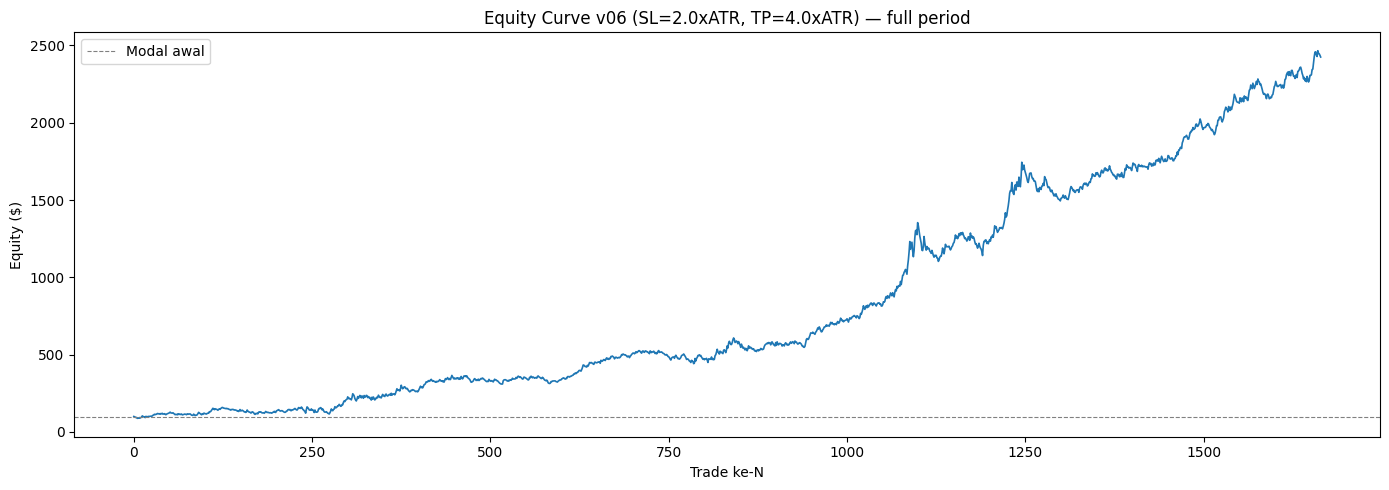

In [10]:
fig, ax = plt.subplots()
ax.plot(equity_curve, linewidth=1.2)
ax.axhline(INITIAL_EQUITY, color="gray", linestyle="--", linewidth=0.8, label="Modal awal")
ax.set_title(f"Equity Curve v06 (SL={SL_MULT}xATR, TP={TP_MULT}xATR) — full period")
ax.set_xlabel("Trade ke-N")
ax.set_ylabel("Equity ($)")
ax.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "equity_curve.png", dpi=120)
plt.show()

## 9. Simpan hasil

In [11]:
trades_df.to_csv(PROCESSED_OUT_DIR / "trade_log_full.csv", index=False)
grid_df.to_csv(EXPORT_DIR / "grid_search_full_period.csv", index=False)
results_2026_df.to_csv(EXPORT_DIR / "grid_search_2026_only.csv", index=False)

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write(f"Backtest v06 — XAUUSD M5 — TP/SL ATR-relatif (fix distribution shift)\n")
    f.write(f"Parameter: MIN_SIGNAL_SCORE={MIN_SIGNAL_SCORE}, require_h1_alignment={REQUIRE_H1_ALIGNMENT}\n")
    f.write(f"SL={SL_MULT}xATR TP={TP_MULT}xATR MAX_HOLD={MAX_HOLD_CANDLES} candle\n\n")
    f.write("=== Full period 2025-2026 ===\n")
    for k, v in metrics.items():
        f.write(f"{k}: {v}\n")
    f.write("\n=== Khusus periode 2026 (rezim harga tinggi, kondisi live trading) ===\n")
    f.write("v04 fixed TP12/SL6:\n")
    for k, v in metrics_v04_2026.items():
        f.write(f"  {k}: {v}\n")
    f.write("v06 ATR-relatif:\n")
    for k, v in metrics_v06_2026.items():
        f.write(f"  {k}: {v}\n")

print("Log lengkap:", PROCESSED_OUT_DIR / "trade_log_full.csv")
print("Ringkasan & grafik:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Log lengkap: D:\Projects\robot-scalping\dataset\processed\m5_scalping\v06\trade_log_full.csv
Ringkasan & grafik: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v06
 - equity_curve.png
 - grid_search_2026_only.csv
 - grid_search_full_period.csv
 - metrics.txt
